# EDA 04 - Revenue Trend Analysis

This notebook analyzes revenue behavior over time using `sales.csv`: daily, monthly, yearly trends, rolling averages, sudden changes, candidate breakpoints, seasonality, volatility, and forecast feature candidates.

## 1. Setup and file discovery

Locate `sales.csv` recursively from the current working directory and configure common plotting/table settings.

In [ ]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd()
SALES_FILENAME = "sales.csv"

sales_matches = sorted(PROJECT_ROOT.rglob(SALES_FILENAME), key=lambda p: (len(p.parts), str(p)))
sales_path = sales_matches[0] if sales_matches else None

file_discovery_df = pd.DataFrame([{
    "file": SALES_FILENAME,
    "found": sales_path is not None,
    "path": str(sales_path.relative_to(PROJECT_ROOT)) if sales_path else None,
    "match_count": len(sales_matches),
}])

print(f"Project root: {PROJECT_ROOT}")
file_discovery_df

Project root: D:\Code\Datathon 2026


,file,found,path,match_count
0,sales.csv,True,datathon-2026-round-1\sales.csv,1


## 2. Load sales data

Load `sales.csv` safely. If it cannot be loaded, later sections display warnings rather than failing.

In [2]:
sales_raw = None
load_error = None

if sales_path is None:
    load_error = "sales.csv was not found."
else:
    try:
        sales_raw = pd.read_csv(sales_path, low_memory=False)
    except Exception as exc:
        load_error = repr(exc)

if sales_raw is None:
    print(f"WARNING: Could not load sales.csv: {load_error}")
    load_summary_df = pd.DataFrame([{"file": SALES_FILENAME, "loaded": False, "rows": np.nan, "columns": np.nan, "error": load_error}])
else:
    load_summary_df = pd.DataFrame([{"file": SALES_FILENAME, "loaded": True, "rows": len(sales_raw), "columns": len(sales_raw.columns), "error": ""}])

display(load_summary_df)
if sales_raw is not None:
    display(sales_raw.head())

,file,loaded,rows,columns,error
0,sales.csv,True,3833,3,


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify date and revenue columns

Detect the most likely date and revenue columns robustly using normalized column names, parse success, and numeric suitability.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_points = 0
    if name in {"date", "sales_date", "order_date"}:
        name_points += 3
    elif "date" in name or "time" in name or "timestamp" in name:
        name_points += 2
    parsed = pd.to_datetime(series, errors="coerce")
    non_null = series.notna().sum()
    success = parsed.notna().sum() / non_null if non_null else 0
    return name_points + success, success, parsed


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = series.astype("string").str.strip().str.replace(",", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")


def revenue_score(column_name, series):
    name = normalize_name(column_name)
    name_points = 0
    if name == "revenue":
        name_points += 5
    elif "revenue" in name or "sales" in name or "amount" in name:
        name_points += 3
    numeric = numeric_series(series)
    non_null = series.notna().sum()
    success = numeric.notna().sum() / non_null if non_null else 0
    positive_share = (numeric.dropna() > 0).mean() if numeric.notna().sum() else 0
    variability = numeric.std(skipna=True) if numeric.notna().sum() else 0
    return name_points + success + positive_share + (1 if variability and variability > 0 else 0), success, numeric

if sales_raw is None:
    column_detection_df = pd.DataFrame([{"warning": "sales.csv not loaded"}])
    date_col = None
    revenue_col = None
    parsed_date = None
    parsed_revenue = None
else:
    date_candidates = []
    revenue_candidates = []
    for col in sales_raw.columns:
        d_score, d_success, d_parsed = date_score(col, sales_raw[col])
        date_candidates.append({"column": col, "date_score": d_score, "date_parse_success": d_success})
        r_score, r_success, r_numeric = revenue_score(col, sales_raw[col])
        revenue_candidates.append({"column": col, "revenue_score": r_score, "numeric_parse_success": r_success})

    date_candidates_df = pd.DataFrame(date_candidates).sort_values("date_score", ascending=False)
    revenue_candidates_df = pd.DataFrame(revenue_candidates).sort_values("revenue_score", ascending=False)
    date_col = date_candidates_df.iloc[0]["column"] if len(date_candidates_df) and date_candidates_df.iloc[0]["date_parse_success"] > 0.5 else None
    revenue_col = revenue_candidates_df.iloc[0]["column"] if len(revenue_candidates_df) and revenue_candidates_df.iloc[0]["numeric_parse_success"] > 0.8 else None
    parsed_date = pd.to_datetime(sales_raw[date_col], errors="coerce") if date_col else None
    parsed_revenue = numeric_series(sales_raw[revenue_col]) if revenue_col else None
    column_detection_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "date_parse_success": parsed_date.notna().mean() if parsed_date is not None else np.nan,
        "revenue_numeric_success": parsed_revenue.notna().mean() if parsed_revenue is not None else np.nan,
    }])

print("Selected columns")
display(column_detection_df)
if sales_raw is not None:
    print("Date candidates")
    display(date_candidates_df)
    print("Revenue candidates")
    display(revenue_candidates_df)

Selected columns


,selected_date_column,selected_revenue_column,date_parse_success,revenue_numeric_success
0,Date,Revenue,1.0,1.0


Date candidates


,column,date_score,date_parse_success
0,Date,4.0,1.0
1,Revenue,1.0,1.0
2,COGS,1.0,1.0


Revenue candidates


,column,revenue_score,numeric_parse_success
1,Revenue,8.0,1.0
2,COGS,3.0,1.0
0,Date,0.0,0.0


## 4. Prepare daily revenue time series

Parse dates and revenue, aggregate to daily granularity if needed, sort by date, and identify missing daily dates.

In [4]:
analysis_ready = sales_raw is not None and date_col is not None and revenue_col is not None

if not analysis_ready:
    print("WARNING: A usable date or revenue column was not found. Analysis sections will be skipped safely.")
    daily = pd.DataFrame(columns=["Date", "Revenue"])
    missing_daily_dates = pd.DatetimeIndex([])
else:
    prepared = pd.DataFrame({"Date": parsed_date, "Revenue": parsed_revenue})
    prepared = prepared.dropna(subset=["Date", "Revenue"])
    prepared["Date"] = prepared["Date"].dt.normalize()
    duplicate_date_count = int(prepared.duplicated(subset=["Date"]).sum())
    daily = prepared.groupby("Date", as_index=False)["Revenue"].sum().sort_values("Date").reset_index(drop=True)
    full_daily_index = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
    present_dates = pd.DatetimeIndex(daily["Date"])
    missing_daily_dates = full_daily_index.difference(present_dates)

    daily_summary_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "raw_rows": len(sales_raw),
        "daily_rows_after_aggregation": len(daily),
        "duplicate_dates_before_aggregation": duplicate_date_count,
        "min_date": daily["Date"].min(),
        "max_date": daily["Date"].max(),
        "calendar_days_between_min_max": len(full_daily_index),
        "missing_daily_dates": len(missing_daily_dates),
        "first_20_missing_dates": [d.strftime("%Y-%m-%d") for d in missing_daily_dates[:20]],
    }])
    display(daily_summary_df)
    display(daily.head())

,selected_date_column,selected_revenue_column,raw_rows,daily_rows_after_aggregation,duplicate_dates_before_aggregation,min_date,max_date,calendar_days_between_min_max,missing_daily_dates,first_20_missing_dates
0,Date,Revenue,3833,3833,0,2012-07-04,2022-12-31,3833,0,[]


,Date,Revenue
0,2012-07-04,5123547.94
1,2012-07-05,2751773.45
2,2012-07-06,3054029.42
3,2012-07-07,2667930.94
4,2012-07-08,2360851.90


## 5. Daily revenue trend

Plot daily revenue and report core descriptive statistics.

,date_range_start,date_range_end,number_of_days,missing_dates_between_min_max,total_revenue,average_daily_revenue,median_daily_revenue,minimum_daily_revenue,maximum_daily_revenue,std_daily_revenue
0,2012-07-04,2022-12-31,3833,0,1.643048e+10,4.286584e+06,3647303.9,279813.94,20905271.35,2.624840e+06


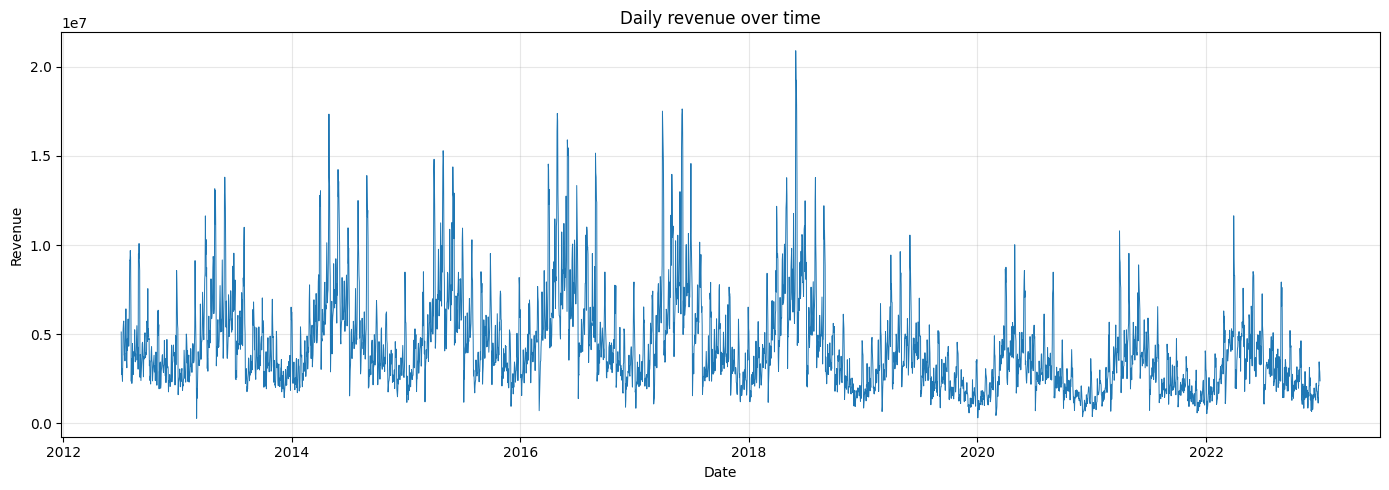

In [5]:
if daily.empty:
    print("Daily revenue analysis skipped because daily series is unavailable.")
    daily_stats_df = pd.DataFrame()
else:
    daily_stats_df = pd.DataFrame([{
        "date_range_start": daily["Date"].min(),
        "date_range_end": daily["Date"].max(),
        "number_of_days": len(daily),
        "missing_dates_between_min_max": len(missing_daily_dates),
        "total_revenue": daily["Revenue"].sum(),
        "average_daily_revenue": daily["Revenue"].mean(),
        "median_daily_revenue": daily["Revenue"].median(),
        "minimum_daily_revenue": daily["Revenue"].min(),
        "maximum_daily_revenue": daily["Revenue"].max(),
        "std_daily_revenue": daily["Revenue"].std(),
    }])
    display(daily_stats_df)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(daily["Date"], daily["Revenue"], linewidth=0.7)
    ax.set_title("Daily revenue over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Monthly revenue trend

Aggregate revenue by month, compute month-over-month growth, and identify best/worst and unusual months.

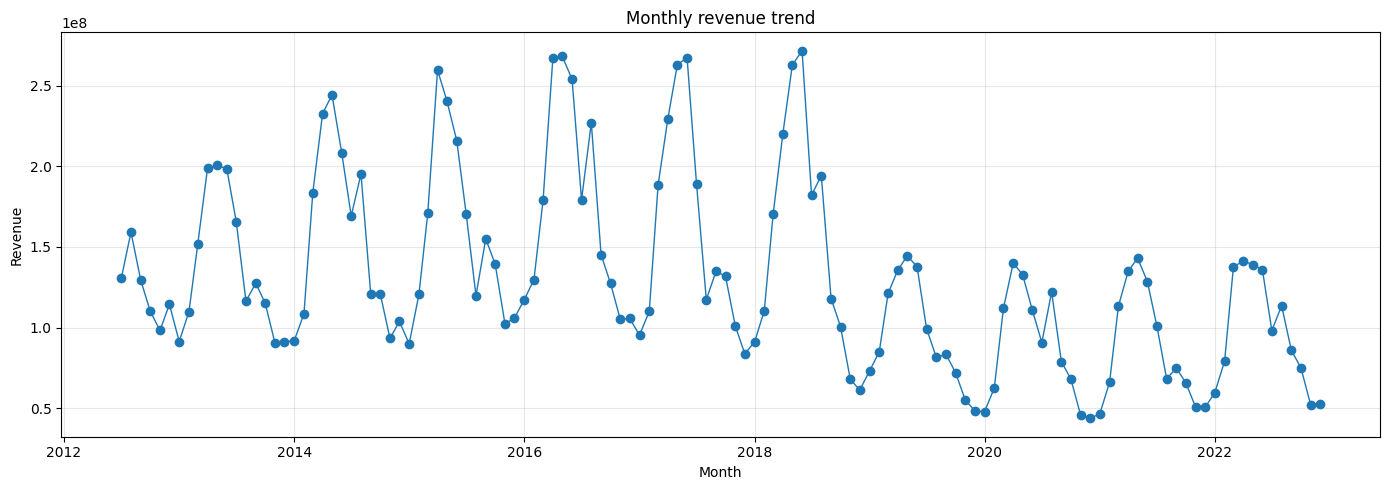

Monthly revenue and growth rates


,Date,Revenue,year_month,mom_abs_change,mom_pct_change,nearby_3mo_mean,nearby_deviation,nearby_deviation_pct
0,2012-07-01,1.304068e+08,2012-07,NaN,NaN,1.447480e+08,-1.434123e+07,-9.907724
1,2012-08-01,1.590892e+08,2012-08,28682466.80,21.994614,1.396010e+08,1.948819e+07,13.959917
2,2012-09-01,1.293071e+08,2012-09,-29782106.49,-18.720378,1.328607e+08,-3.553556e+06,-2.674648
3,2012-10-01,1.101857e+08,2012-10,-19121439.37,-14.787614,1.125597e+08,-2.374013e+06,-2.109115
4,2012-11-01,9.818630e+07,2012-11,-11999399.21,-10.890161,1.075649e+08,-9.378572e+06,-8.718991
5,2012-12-01,1.143226e+08,2012-12,16136315.45,16.434387,1.012725e+08,1.305008e+07,12.886104
6,2013-01-01,9.130868e+07,2013-01,-23013933.66,-20.130693,1.051381e+08,-1.382946e+07,-13.153614
7,2013-02-01,1.097831e+08,2013-02,18474460.91,20.232974,1.176422e+08,-7.859019e+06,-6.680445
8,2013-03-01,1.518347e+08,2013-03,42051519.33,38.304170,1.535149e+08,-1.680252e+06,-1.094520
9,2013-04-01,1.989269e+08,2013-04,47092274.82,31.015498,1.837539e+08,1.517303e+07,8.257257


Best revenue months


,year_month,Revenue,mom_abs_change,mom_pct_change
71,2018-06,2.716742e+08,8895669.11,3.385235
46,2016-05,2.681319e+08,1018117.65,0.381155
59,2017-06,2.674333e+08,4524495.83,1.720937
45,2016-04,2.671138e+08,87967916.52,49.104077
58,2017-05,2.629088e+08,33381950.65,14.543808
70,2018-05,2.627785e+08,42554935.24,19.323515
33,2015-04,2.596944e+08,88754109.79,51.921110
47,2016-06,2.539394e+08,-14192502.51,-5.293105
22,2014-05,2.443095e+08,11743901.02,5.049715
34,2015-05,2.403847e+08,-19309738.65,-7.435561


Worst revenue months


,year_month,Revenue,mom_abs_change,mom_pct_change
101,2020-12,43671563.77,-2069317.68,-4.524000
100,2020-11,45740881.45,-22395581.48,-32.868717
102,2021-01,46473094.42,2801530.65,6.415000
90,2020-01,47728257.00,-703299.19,-1.452151
89,2019-12,48431556.19,-6576719.84,-11.955873
113,2021-12,50403908.35,-234589.11,-0.463262
112,2021-11,50638497.46,-15053638.70,-22.915435
124,2022-11,52200081.64,-22994370.67,-30.579877
125,2022-12,52454936.20,254854.56,0.488226
88,2019-11,55008276.03,-17049584.99,-23.660965


Months with largest deviation from nearby 3-month average


,year_month,Revenue,nearby_3mo_mean,nearby_deviation,nearby_deviation_pct
49,2016-08,2.270085e+08,1.837761e+08,4.323240e+07,23.524498
48,2016-07,1.791667e+08,2.200382e+08,-4.087151e+07,-18.574738
33,2015-04,2.596944e+08,2.236731e+08,3.602128e+07,16.104429
72,2018-07,1.820708e+08,2.160069e+08,-3.393609e+07,-15.710650
25,2014-08,1.952658e+08,1.616818e+08,3.358405e+07,20.771699
71,2018-06,2.716742e+08,2.388412e+08,3.283301e+07,13.746795
61,2017-08,1.172974e+08,1.470786e+08,-2.978121e+07,-20.248505
73,2018-08,1.942757e+08,1.647719e+08,2.950382e+07,17.905854
45,2016-04,2.671138e+08,2.381305e+08,2.898327e+07,12.171169
37,2015-08,1.198550e+08,1.483742e+08,-2.851925e+07,-19.221161


In [6]:
if daily.empty:
    print("Monthly revenue analysis skipped because daily series is unavailable.")
    monthly = pd.DataFrame()
else:
    monthly = daily.set_index("Date")["Revenue"].resample("MS").sum().reset_index()
    monthly["year_month"] = monthly["Date"].dt.to_period("M").astype(str)
    monthly["mom_abs_change"] = monthly["Revenue"].diff()
    monthly["mom_pct_change"] = monthly["Revenue"].pct_change().replace([np.inf, -np.inf], np.nan) * 100
    monthly["nearby_3mo_mean"] = monthly["Revenue"].rolling(3, center=True, min_periods=2).mean()
    monthly["nearby_deviation"] = monthly["Revenue"] - monthly["nearby_3mo_mean"]
    monthly["nearby_deviation_pct"] = monthly["nearby_deviation"] / monthly["nearby_3mo_mean"] * 100

    best_months_df = monthly.nlargest(10, "Revenue")[["year_month", "Revenue", "mom_abs_change", "mom_pct_change"]]
    worst_months_df = monthly.nsmallest(10, "Revenue")[["year_month", "Revenue", "mom_abs_change", "mom_pct_change"]]
    unusual_months_df = monthly.reindex(monthly["nearby_deviation"].abs().sort_values(ascending=False).index).head(15)[
        ["year_month", "Revenue", "nearby_3mo_mean", "nearby_deviation", "nearby_deviation_pct"]
    ]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly["Date"], monthly["Revenue"], marker="o", linewidth=1)
    ax.set_title("Monthly revenue trend")
    ax.set_xlabel("Month")
    ax.set_ylabel("Revenue")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Monthly revenue and growth rates")
    display(monthly)
    print("Best revenue months")
    display(best_months_df)
    print("Worst revenue months")
    display(worst_months_df)
    print("Months with largest deviation from nearby 3-month average")
    display(unusual_months_df)

## 7. Yearly revenue trend

Aggregate revenue by year, compute year-over-year growth, and identify best/worst years and broad trend direction.

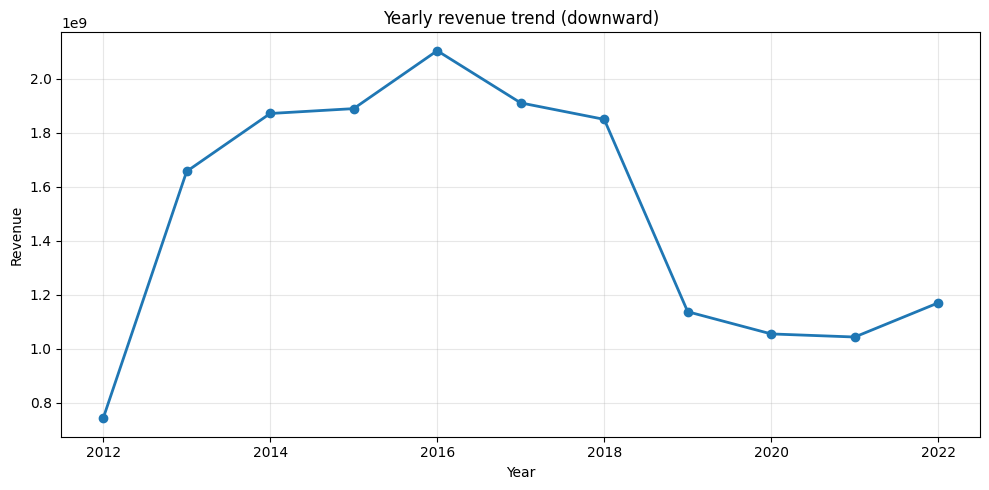

,trend_direction_by_linear_slope,linear_slope_per_year_index,best_year,best_year_revenue,worst_year,worst_year_revenue
0,downward,-4.116406e+07,2016,2.104641e+09,2012,7.414977e+08


,year,Revenue,yoy_abs_change,yoy_pct_change,avg_daily_revenue
0,2012,7.414977e+08,NaN,NaN,4.096673e+06
1,2013,1.657169e+09,9.156717e+08,123.489474,4.540190e+06
2,2014,1.871846e+09,2.146765e+08,12.954407,5.128345e+06
3,2015,1.889934e+09,1.808794e+07,0.966316,5.177901e+06
4,2016,2.104641e+09,2.147069e+08,11.360549,5.750384e+06
5,2017,1.911164e+09,-1.934764e+08,-9.192845,5.236067e+06
6,2018,1.850122e+09,-6.104187e+07,-3.193962,5.068829e+06
7,2019,1.136801e+09,-7.133210e+08,-38.555341,3.114524e+06
8,2020,1.054512e+09,-8.228928e+07,-7.238668,2.881181e+06
9,2021,1.043040e+09,-1.147234e+07,-1.087929,2.857643e+06


In [7]:
if daily.empty:
    print("Yearly revenue analysis skipped because daily series is unavailable.")
    yearly = pd.DataFrame()
else:
    yearly = daily.assign(year=daily["Date"].dt.year).groupby("year", as_index=False)["Revenue"].sum()
    yearly["yoy_abs_change"] = yearly["Revenue"].diff()
    yearly["yoy_pct_change"] = yearly["Revenue"].pct_change().replace([np.inf, -np.inf], np.nan) * 100
    yearly["avg_daily_revenue"] = daily.assign(year=daily["Date"].dt.year).groupby("year")["Revenue"].mean().values

    trend_slope = np.polyfit(np.arange(len(yearly)), yearly["Revenue"], 1)[0] if len(yearly) >= 2 else np.nan
    trend_direction = "upward" if trend_slope > 0 else "downward" if trend_slope < 0 else "flat/unknown"

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly["year"], yearly["Revenue"], marker="o", linewidth=2)
    ax.set_title(f"Yearly revenue trend ({trend_direction})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Revenue")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    yearly_summary_df = pd.DataFrame([{
        "trend_direction_by_linear_slope": trend_direction,
        "linear_slope_per_year_index": trend_slope,
        "best_year": int(yearly.loc[yearly["Revenue"].idxmax(), "year"]),
        "best_year_revenue": yearly["Revenue"].max(),
        "worst_year": int(yearly.loc[yearly["Revenue"].idxmin(), "year"]),
        "worst_year_revenue": yearly["Revenue"].min(),
    }])
    display(yearly_summary_df)
    display(yearly)

## 8. Rolling mean analysis

Compute 30-day, 90-day, and 365-day rolling means to describe short-, medium-, and long-term movements. Also flag days that deviate strongly from rolling averages.

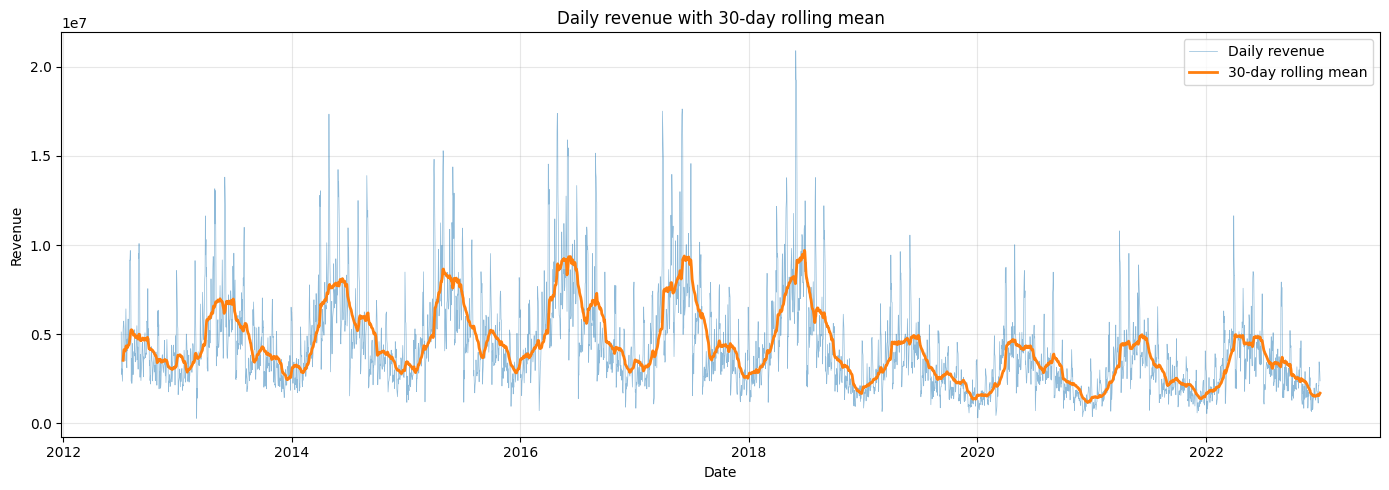

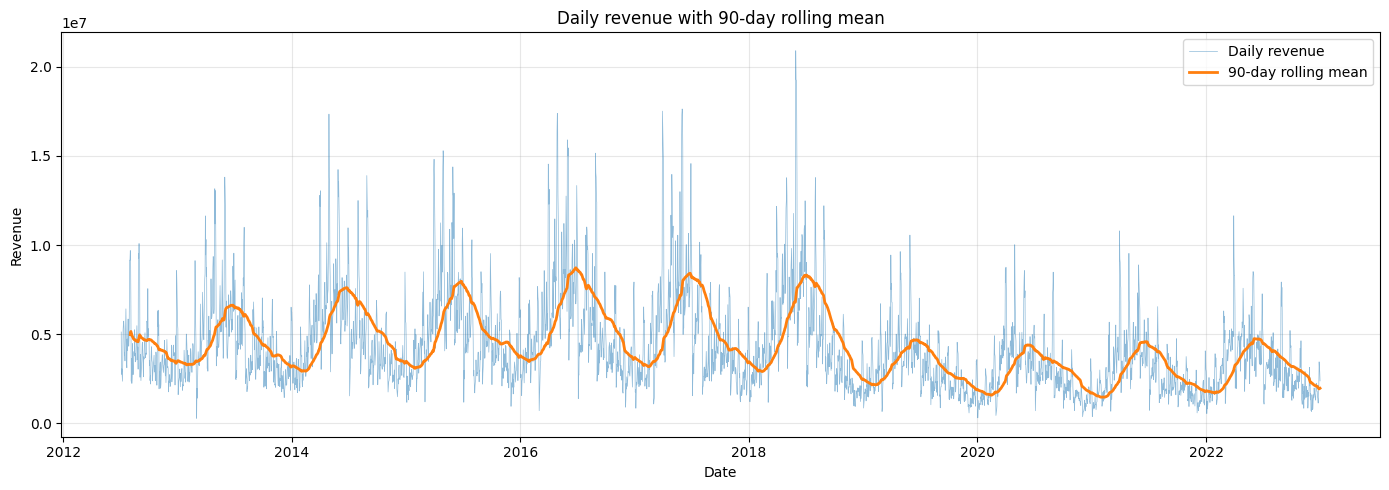

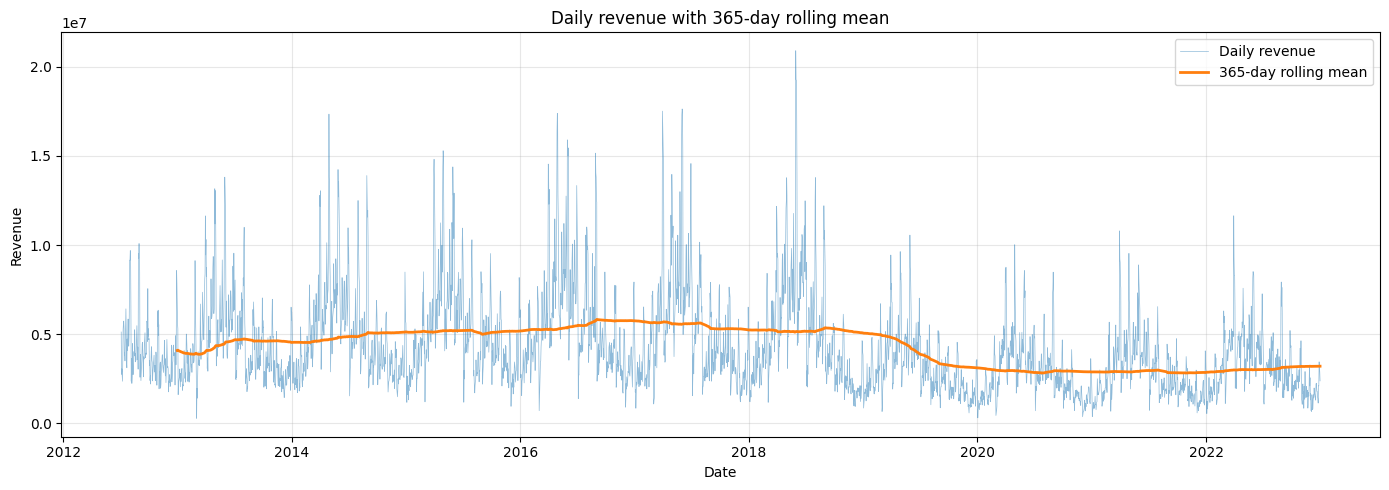

Days with strongest absolute deviation from 90-day rolling mean


,Date,Revenue,rolling_mean_90,deviation_from_90,abs_deviation_from_90
2156,2018-05-30,20905271.35,6.964926e+06,1.394035e+07,1.394035e+07
1730,2017-03-30,17516038.82,4.245011e+06,1.327103e+07,1.327103e+07
1731,2017-03-31,16556662.03,4.373755e+06,1.218291e+07,1.218291e+07
2157,2018-05-31,19289944.12,7.116884e+06,1.217306e+07,1.217306e+07
2158,2018-06-01,19245165.78,7.317641e+06,1.192753e+07,1.192753e+07
664,2014-04-29,17347427.27,5.758731e+06,1.158870e+07,1.158870e+07
1732,2017-04-01,15808755.61,4.504975e+06,1.130378e+07,1.130378e+07
1394,2016-04-28,17388183.19,6.216495e+06,1.117169e+07,1.117169e+07
1395,2016-04-29,16966030.50,6.328108e+06,1.063792e+07,1.063792e+07
1000,2015-03-31,14813965.34,4.238927e+06,1.057504e+07,1.057504e+07


In [8]:
if daily.empty:
    print("Rolling analysis skipped because daily series is unavailable.")
else:
    daily = daily.sort_values("Date").reset_index(drop=True)
    daily["rolling_mean_30"] = daily["Revenue"].rolling(30, min_periods=7).mean()
    daily["rolling_mean_90"] = daily["Revenue"].rolling(90, min_periods=30).mean()
    daily["rolling_mean_365"] = daily["Revenue"].rolling(365, min_periods=180).mean()
    daily["rolling_std_30"] = daily["Revenue"].rolling(30, min_periods=7).std()
    daily["rolling_std_90"] = daily["Revenue"].rolling(90, min_periods=30).std()
    daily["deviation_from_30"] = daily["Revenue"] - daily["rolling_mean_30"]
    daily["deviation_from_90"] = daily["Revenue"] - daily["rolling_mean_90"]
    daily["deviation_from_365"] = daily["Revenue"] - daily["rolling_mean_365"]
    daily["abs_deviation_from_90"] = daily["deviation_from_90"].abs()

    for window in [30, 90, 365]:
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(daily["Date"], daily["Revenue"], linewidth=0.5, alpha=0.5, label="Daily revenue")
        ax.plot(daily["Date"], daily[f"rolling_mean_{window}"], linewidth=2, label=f"{window}-day rolling mean")
        ax.set_title(f"Daily revenue with {window}-day rolling mean")
        ax.set_xlabel("Date")
        ax.set_ylabel("Revenue")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    strong_deviation_df = daily.dropna(subset=["rolling_mean_90"]).nlargest(15, "abs_deviation_from_90")[
        ["Date", "Revenue", "rolling_mean_90", "deviation_from_90", "abs_deviation_from_90"]
    ]
    print("Days with strongest absolute deviation from 90-day rolling mean")
    display(strong_deviation_df)

## 9. Sudden increase/decrease detection

Calculate day-over-day and month-over-month changes, then flag the largest positive and negative changes. Percentage changes are masked when the prior value is too small.

In [9]:
if daily.empty:
    print("Sudden change analysis skipped because daily series is unavailable.")
else:
    daily["dod_abs_change"] = daily["Revenue"].diff()
    previous_daily = daily["Revenue"].shift(1)
    min_daily_denominator = max(1.0, daily["Revenue"].quantile(0.05) * 0.1)
    daily["dod_pct_change"] = np.where(previous_daily.abs() > min_daily_denominator, daily["dod_abs_change"] / previous_daily * 100, np.nan)

    top_daily_increases_df = daily.nlargest(15, "dod_abs_change")[["Date", "Revenue", "dod_abs_change", "dod_pct_change"]]
    top_daily_decreases_df = daily.nsmallest(15, "dod_abs_change")[["Date", "Revenue", "dod_abs_change", "dod_pct_change"]]

    monthly["mom_abs_change"] = monthly["Revenue"].diff()
    previous_monthly = monthly["Revenue"].shift(1)
    min_monthly_denominator = max(1.0, monthly["Revenue"].quantile(0.05) * 0.1)
    monthly["mom_pct_change_safe"] = np.where(previous_monthly.abs() > min_monthly_denominator, monthly["mom_abs_change"] / previous_monthly * 100, np.nan)
    top_monthly_increases_df = monthly.nlargest(12, "mom_abs_change")[["year_month", "Revenue", "mom_abs_change", "mom_pct_change_safe"]]
    top_monthly_decreases_df = monthly.nsmallest(12, "mom_abs_change")[["year_month", "Revenue", "mom_abs_change", "mom_pct_change_safe"]]

    print("Top sudden daily increases")
    display(top_daily_increases_df)
    print("Top sudden daily decreases")
    display(top_daily_decreases_df)
    print("Top month-over-month increases")
    display(top_monthly_increases_df)
    print("Top month-over-month decreases")
    display(top_monthly_decreases_df)

Top sudden daily increases


,Date,Revenue,dod_abs_change,dod_pct_change
2156,2018-05-30,20905271.35,10642453.03,103.699127
1516,2016-08-28,15158669.18,10597021.41,232.306876
1426,2016-05-30,15902645.06,9625258.35,153.332251
1730,2017-03-30,17516038.82,8676228.06,98.149477
999,2015-03-30,14251354.04,8163453.34,134.093076
1791,2017-05-30,15437626.24,7924132.06,105.465338
1365,2016-03-30,14545392.64,7023613.70,93.377029
1060,2015-05-30,14386454.27,6943053.94,93.277986
3556,2022-03-30,11643208.73,6734704.24,137.204810
3191,2021-03-30,10795905.35,6705814.75,163.952719


Top sudden daily decreases


,Date,Revenue,dod_abs_change,dod_pct_change
1431,2016-06-04,3543917.94,-11361301.29,-76.223644
1796,2017-06-04,4982217.86,-10326038.28,-67.454047
1521,2016-09-02,2363186.38,-10040358.24,-80.947492
2161,2018-06-04,4373078.45,-9406623.62,-68.264347
1065,2015-06-04,4389371.30,-8526528.52,-66.015753
790,2014-09-02,1980913.22,-8325628.03,-80.780039
1735,2017-04-04,3822590.98,-8164332.70,-68.110325
2191,2018-07-04,2096565.20,-6936495.55,-76.790091
639,2014-04-04,3027057.03,-6615412.74,-68.607036
2130,2018-05-04,3081716.09,-6398489.45,-67.493151


Top month-over-month increases


,year_month,Revenue,mom_abs_change,mom_pct_change_safe
33,2015-04,2.596944e+08,88754109.79,51.921110
45,2016-04,2.671138e+08,87967916.52,49.104077
56,2017-03,1.883824e+08,78398586.31,71.281901
20,2014-03,1.835139e+08,75072924.94,69.229309
68,2018-03,1.700950e+08,59782196.50,54.193341
116,2022-03,1.375379e+08,58434853.78,73.871766
32,2015-03,1.709403e+08,50257857.83,41.644709
69,2018-04,2.202236e+08,50128563.21,29.470920
44,2016-03,1.791458e+08,49450728.15,38.128441
92,2020-03,1.118044e+08,49355685.85,79.033983


Top month-over-month decreases


,year_month,Revenue,mom_abs_change,mom_pct_change_safe
72,2018-07,1.820708e+08,-89603348.76,-32.981917
50,2016-09,1.451531e+08,-81855378.82,-36.058289
60,2017-07,1.889944e+08,-78438934.36,-29.330275
74,2018-09,1.179692e+08,-76306537.20,-39.277439
48,2016-07,1.791667e+08,-74772716.18,-29.445105
26,2014-09,1.206215e+08,-74644280.64,-38.227008
61,2017-08,1.172974e+08,-71697045.57,-37.936067
37,2015-08,1.198550e+08,-50382061.85,-29.595239
13,2013-08,1.162718e+08,-49473598.03,-29.849161
36,2015-07,1.702370e+08,-45599343.09,-21.126809


## 10. Breakpoint / structural change exploration

Use simple, interpretable rolling before/after comparisons to flag candidate level shifts. These are exploratory candidates, not causal conclusions.

In [10]:
if daily.empty:
    print("Breakpoint analysis skipped because daily series is unavailable.")
    breakpoint_candidates_df = pd.DataFrame()
else:
    bp = daily[["Date", "Revenue"]].copy()
    window = 180
    bp["before_mean_180"] = bp["Revenue"].shift(1).rolling(window, min_periods=90).mean()
    bp["after_mean_180"] = bp["Revenue"].shift(-window).rolling(window, min_periods=90).mean()
    bp["abs_difference"] = bp["after_mean_180"] - bp["before_mean_180"]
    bp["pct_difference"] = bp["abs_difference"] / bp["before_mean_180"] * 100
    bp["abs_pct_difference"] = bp["pct_difference"].abs()
    bp = bp.dropna(subset=["before_mean_180", "after_mean_180", "pct_difference"])

    # Keep candidate dates at least 90 days apart to avoid showing the same transition repeatedly.
    selected = []
    for _, row in bp.sort_values("abs_pct_difference", ascending=False).iterrows():
        candidate_date = row["Date"]
        if all(abs((candidate_date - prior).days) >= 90 for prior in selected):
            selected.append(candidate_date)
        if len(selected) >= 12:
            break

    breakpoint_candidates_df = bp[bp["Date"].isin(selected)].copy()
    breakpoint_candidates_df["reason_flagged"] = np.where(
        breakpoint_candidates_df["abs_difference"] > 0,
        "candidate sustained level increase",
        "candidate sustained level decrease",
    )
    breakpoint_candidates_df = breakpoint_candidates_df[
        ["Date", "before_mean_180", "after_mean_180", "abs_difference", "pct_difference", "reason_flagged"]
    ].sort_values("Date")

    display(breakpoint_candidates_df)

,Date,before_mean_180,after_mean_180,abs_difference,pct_difference,reason_flagged
250,2013-03-11,3.531384e+06,5.729896e+06,2.198512e+06,62.256381,candidate sustained level increase
609,2014-03-05,3.434144e+06,6.779001e+06,3.344856e+06,97.399995,candidate sustained level increase
974,2015-03-05,3.566059e+06,6.489010e+06,2.922952e+06,81.965886,candidate sustained level increase
1342,2016-03-07,4.049881e+06,7.631438e+06,3.581557e+06,88.436098,candidate sustained level increase
1525,2016-09-06,7.616575e+06,3.720171e+06,-3.896404e+06,-51.156907,candidate sustained level decrease
1706,2017-03-06,3.720171e+06,6.958730e+06,3.238559e+06,87.054057,candidate sustained level increase
2071,2018-03-06,3.586410e+06,7.171995e+06,3.585585e+06,99.976986,candidate sustained level increase
2259,2018-09-10,7.137780e+06,2.712284e+06,-4.425496e+06,-62.001013,candidate sustained level decrease
2804,2020-03-08,1.988841e+06,3.923063e+06,1.934222e+06,97.253762,candidate sustained level increase
2987,2020-09-07,3.920067e+06,1.893398e+06,-2.026669e+06,-51.699849,candidate sustained level decrease


## 11. Seasonality and volatility insights

Quantify month-of-year, day-of-week, quarter-level patterns, prolonged growth/decline periods, and volatility changes.

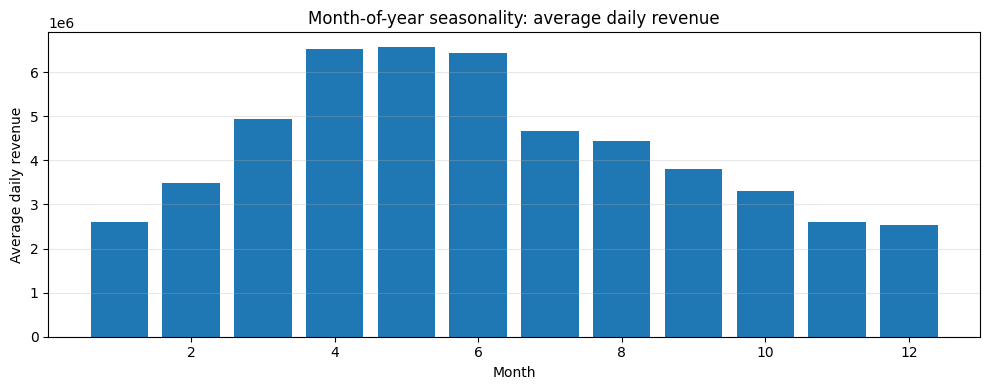

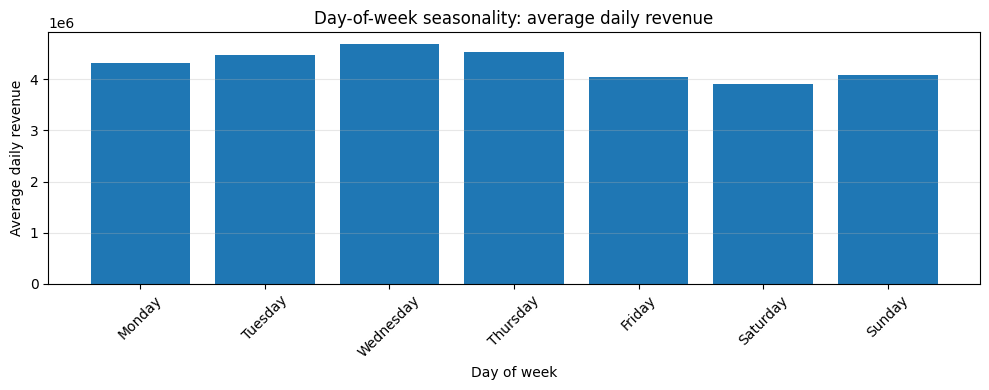

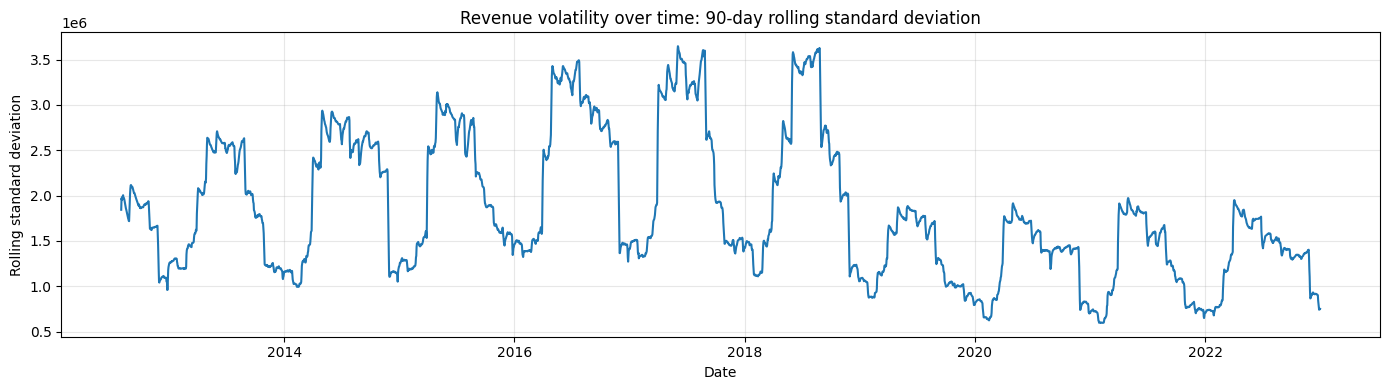

Month-of-year seasonality


,month,avg_daily_revenue,median_daily_revenue,total_revenue,observation_count
0,1,2.591155e+06,2416732.695,8.032579e+08,310
1,2,3.480801e+06,3242762.870,9.815858e+08,282
2,3,4.928185e+06,4606234.990,1.527737e+09,310
3,4,6.532952e+06,5795217.085,1.959886e+09,300
4,5,6.575416e+06,6067768.610,2.038379e+09,310
5,6,6.427109e+06,5826463.100,1.928133e+09,300
6,7,4.659789e+06,4379419.245,1.575009e+09,338
7,8,4.441193e+06,3646382.120,1.514447e+09,341
8,9,3.797826e+06,3604251.200,1.253282e+09,330
9,10,3.302725e+06,3172297.010,1.126229e+09,341


Day-of-week seasonality


,day_of_week,avg_daily_revenue,median_daily_revenue,observation_count
0,Monday,4.311035e+06,3848593.440,547
1,Tuesday,4.465103e+06,3925730.260,547
2,Wednesday,4.680065e+06,3929024.180,548
3,Thursday,4.523044e+06,3629496.985,548
4,Friday,4.046390e+06,3359439.985,548
5,Saturday,3.906581e+06,3384605.360,548
6,Sunday,4.073854e+06,3603536.480,547


Quarter-level trends


,year,quarter,revenue,avg_daily_revenue,days,quarter_label,qoq_pct_change
0,2012,3,4.188031e+08,4.705653e+06,89,2012Q3,NaN
1,2012,4,3.226946e+08,3.507550e+06,92,2012Q4,-22.948382
2,2013,1,3.529265e+08,3.921405e+06,90,2013Q1,9.368571
3,2013,2,5.979447e+08,6.570821e+06,91,2013Q2,69.424715
4,2013,3,4.095513e+08,4.451644e+06,92,2013Q3,-31.506830
5,2013,4,2.967470e+08,3.225511e+06,92,2013Q4,-27.543376
6,2014,1,3.837586e+08,4.263984e+06,90,2014Q1,29.321790
7,2014,2,6.850090e+08,7.527571e+06,91,2014Q2,78.499987
8,2014,3,4.850453e+08,5.272232e+06,92,2014Q3,-29.191393
9,2014,4,3.180331e+08,3.456881e+06,92,2014Q4,-34.432300


Prolonged growth/decline runs by month


,direction,start_month,end_month,length_months,total_abs_change
30,growth,2018-01,2018-06,6,1.879344e+08
20,growth,2015-12,2016-05,6,1.658201e+08
8,growth,2013-12,2014-05,6,1.539382e+08
26,growth,2017-02,2017-06,5,1.721617e+08
42,growth,2021-01,2021-05,5,9.939913e+07
34,growth,2019-01,2019-05,5,8.317325e+07
4,growth,2013-02,2013-05,4,1.091914e+08
46,growth,2022-01,2022-04,4,9.090160e+07
37,decline,2019-10,2020-01,4,-3.556247e+07
41,decline,2020-09,2020-12,4,-7.839345e+07


Volatility by year


,year,avg_rolling_std_90,daily_revenue_std,avg_daily_revenue,coef_variation
0,2012,1.687897e+06,1.684324e+06,4.096673e+06,0.411144
1,2013,1.863559e+06,2.272147e+06,4.540190e+06,0.500452
2,2014,2.110789e+06,2.677531e+06,5.128345e+06,0.522104
3,2015,2.091687e+06,2.645186e+06,5.177901e+06,0.510861
4,2016,2.463621e+06,3.087505e+06,5.750384e+06,0.536922
5,2017,2.362719e+06,3.075067e+06,5.236067e+06,0.587286
6,2018,2.303807e+06,3.168626e+06,5.068829e+06,0.625120
7,2019,1.323942e+06,1.642734e+06,3.114524e+06,0.527443
8,2020,1.302718e+06,1.637312e+06,2.881181e+06,0.568278
9,2021,1.235855e+06,1.644091e+06,2.857643e+06,0.575331


In [11]:
if daily.empty:
    print("Seasonality and volatility analysis skipped because daily series is unavailable.")
else:
    daily["year"] = daily["Date"].dt.year
    daily["quarter"] = daily["Date"].dt.quarter
    daily["month"] = daily["Date"].dt.month
    daily["day_of_week"] = daily["Date"].dt.day_name()

    month_seasonality_df = daily.groupby("month").agg(
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        total_revenue=("Revenue", "sum"),
        observation_count=("Revenue", "size"),
    ).reset_index()

    dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_seasonality_df = daily.groupby("day_of_week").agg(
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        observation_count=("Revenue", "size"),
    ).reindex(dow_order).reset_index()

    quarter_trend_df = daily.groupby(["year", "quarter"]).agg(
        revenue=("Revenue", "sum"),
        avg_daily_revenue=("Revenue", "mean"),
        days=("Revenue", "size"),
    ).reset_index()
    quarter_trend_df["quarter_label"] = quarter_trend_df["year"].astype(str) + "Q" + quarter_trend_df["quarter"].astype(str)
    quarter_trend_df["qoq_pct_change"] = quarter_trend_df["revenue"].pct_change() * 100

    monthly_direction = monthly[["Date", "year_month", "Revenue", "mom_abs_change"]].copy()
    monthly_direction["direction"] = np.where(monthly_direction["mom_abs_change"] > 0, "growth", np.where(monthly_direction["mom_abs_change"] < 0, "decline", "flat"))
    runs = []
    current_direction = None
    run_start = None
    run_values = []
    for _, row in monthly_direction.dropna(subset=["mom_abs_change"]).iterrows():
        if row["direction"] != current_direction:
            if current_direction in {"growth", "decline"} and run_values:
                runs.append({
                    "direction": current_direction,
                    "start_month": run_start,
                    "end_month": previous_month,
                    "length_months": len(run_values),
                    "total_abs_change": sum(run_values),
                })
            current_direction = row["direction"]
            run_start = row["year_month"]
            run_values = []
        run_values.append(row["mom_abs_change"])
        previous_month = row["year_month"]
    if current_direction in {"growth", "decline"} and run_values:
        runs.append({
            "direction": current_direction,
            "start_month": run_start,
            "end_month": previous_month,
            "length_months": len(run_values),
            "total_abs_change": sum(run_values),
        })
    prolonged_runs_df = pd.DataFrame(runs).sort_values(["length_months", "total_abs_change"], ascending=[False, False]).head(15) if runs else pd.DataFrame()

    daily["rolling_std_90"] = daily["Revenue"].rolling(90, min_periods=30).std()
    volatility_by_year_df = daily.groupby("year").agg(
        avg_rolling_std_90=("rolling_std_90", "mean"),
        daily_revenue_std=("Revenue", "std"),
        avg_daily_revenue=("Revenue", "mean"),
    ).reset_index()
    volatility_by_year_df["coef_variation"] = volatility_by_year_df["daily_revenue_std"] / volatility_by_year_df["avg_daily_revenue"]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(month_seasonality_df["month"], month_seasonality_df["avg_daily_revenue"])
    ax.set_title("Month-of-year seasonality: average daily revenue")
    ax.set_xlabel("Month")
    ax.set_ylabel("Average daily revenue")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(dow_seasonality_df["day_of_week"], dow_seasonality_df["avg_daily_revenue"])
    ax.set_title("Day-of-week seasonality: average daily revenue")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Average daily revenue")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(daily["Date"], daily["rolling_std_90"], linewidth=1.5)
    ax.set_title("Revenue volatility over time: 90-day rolling standard deviation")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling standard deviation")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Month-of-year seasonality")
    display(month_seasonality_df)
    print("Day-of-week seasonality")
    display(dow_seasonality_df)
    print("Quarter-level trends")
    display(quarter_trend_df)
    print("Prolonged growth/decline runs by month")
    display(prolonged_runs_df)
    print("Volatility by year")
    display(volatility_by_year_df)

## 12. Forecast feature preview

Create a preview of time-series features that could be used for forecasting. Rolling and lag features use only current and past rows, not future data.

In [12]:
if daily.empty:
    print("Feature preview skipped because daily series is unavailable.")
    feature_preview_df = pd.DataFrame()
else:
    feature_table = daily[["Date", "Revenue"]].copy().sort_values("Date").reset_index(drop=True)
    feature_table["time_index"] = np.arange(len(feature_table))
    feature_table["year"] = feature_table["Date"].dt.year
    feature_table["quarter"] = feature_table["Date"].dt.quarter
    feature_table["month"] = feature_table["Date"].dt.month
    feature_table["month_index"] = (feature_table["year"] - feature_table["year"].min()) * 12 + feature_table["month"]
    feature_table["week_of_year"] = feature_table["Date"].dt.isocalendar().week.astype(int)
    feature_table["day_of_week"] = feature_table["Date"].dt.dayofweek
    feature_table["day_of_month"] = feature_table["Date"].dt.day
    feature_table["day_of_year"] = feature_table["Date"].dt.dayofyear
    feature_table["is_month_start"] = feature_table["Date"].dt.is_month_start.astype(int)
    feature_table["is_month_end"] = feature_table["Date"].dt.is_month_end.astype(int)
    feature_table["rolling_mean_30"] = feature_table["Revenue"].rolling(30, min_periods=7).mean()
    feature_table["rolling_mean_90"] = feature_table["Revenue"].rolling(90, min_periods=30).mean()
    feature_table["rolling_mean_365"] = feature_table["Revenue"].rolling(365, min_periods=180).mean()
    feature_table["rolling_std_30"] = feature_table["Revenue"].rolling(30, min_periods=7).std()
    feature_table["rolling_std_90"] = feature_table["Revenue"].rolling(90, min_periods=30).std()
    feature_table["lag_1"] = feature_table["Revenue"].shift(1)
    feature_table["lag_7"] = feature_table["Revenue"].shift(7)
    feature_table["lag_30"] = feature_table["Revenue"].shift(30)
    feature_table["trend_feature"] = feature_table["time_index"]

    feature_preview_df = pd.concat([feature_table.head(10), feature_table.tail(10)], ignore_index=True)
    display(feature_preview_df)

,Date,Revenue,time_index,year,quarter,month,month_index,week_of_year,day_of_week,day_of_month,day_of_year,is_month_start,is_month_end,rolling_mean_30,rolling_mean_90,rolling_mean_365,rolling_std_30,rolling_std_90,lag_1,lag_7,lag_30,trend_feature
0,2012-07-04,5123547.94,0,2012,3,7,7,27,2,4,186,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2012-07-05,2751773.45,1,2012,3,7,7,27,3,5,187,0,0,NaN,NaN,NaN,NaN,NaN,5123547.94,NaN,NaN,1
2,2012-07-06,3054029.42,2,2012,3,7,7,27,4,6,188,0,0,NaN,NaN,NaN,NaN,NaN,2751773.45,NaN,NaN,2
3,2012-07-07,2667930.94,3,2012,3,7,7,27,5,7,189,0,0,NaN,NaN,NaN,NaN,NaN,3054029.42,NaN,NaN,3
4,2012-07-08,2360851.90,4,2012,3,7,7,27,6,8,190,0,0,NaN,NaN,NaN,NaN,NaN,2667930.94,NaN,NaN,4
5,2012-07-09,3548386.46,5,2012,3,7,7,28,0,9,191,0,0,NaN,NaN,NaN,NaN,NaN,2360851.90,NaN,NaN,5
6,2012-07-10,5234938.62,6,2012,3,7,7,28,1,10,192,0,0,3.534494e+06,NaN,NaN,1.182417e+06,NaN,3548386.46,NaN,NaN,6
7,2012-07-11,5582884.78,7,2012,3,7,7,28,2,11,193,0,0,3.790543e+06,NaN,NaN,1.312581e+06,NaN,5234938.62,5123547.94,NaN,7
8,2012-07-12,5734632.02,8,2012,3,7,7,28,3,12,194,0,0,4.006553e+06,NaN,NaN,1.388327e+06,NaN,5582884.78,2751773.45,NaN,8
9,2012-07-13,5309511.71,9,2012,3,7,7,28,4,13,195,0,0,4.136849e+06,NaN,NaN,1.372247e+06,NaN,5734632.02,3054029.42,NaN,9


## 13. Key observations and warnings

Print a concise summary of trend direction, growth/decline periods, candidate breakpoints, seasonality, volatility, suspicious periods for later investigation, and recommended forecast features.

In [13]:
if daily.empty:
    print("No final insight summary because a usable daily revenue series was not available.")
else:
    strongest_growth_periods = top_monthly_increases_df.head(5)[["year_month", "mom_abs_change", "mom_pct_change_safe"]].to_dict("records")
    strongest_decline_periods = top_monthly_decreases_df.head(5)[["year_month", "mom_abs_change", "mom_pct_change_safe"]].to_dict("records")
    breakpoint_periods = breakpoint_candidates_df.head(8).to_dict("records") if len(breakpoint_candidates_df) else []
    best_month = month_seasonality_df.loc[month_seasonality_df["avg_daily_revenue"].idxmax()].to_dict()
    worst_month = month_seasonality_df.loc[month_seasonality_df["avg_daily_revenue"].idxmin()].to_dict()
    best_dow = dow_seasonality_df.loc[dow_seasonality_df["avg_daily_revenue"].idxmax()].to_dict()
    worst_dow = dow_seasonality_df.loc[dow_seasonality_df["avg_daily_revenue"].idxmin()].to_dict()
    highest_vol_year = volatility_by_year_df.loc[volatility_by_year_df["coef_variation"].idxmax()].to_dict()
    suspicious_periods = unusual_months_df.head(8)[["year_month", "Revenue", "nearby_deviation", "nearby_deviation_pct"]].to_dict("records")
    recommended_features = [
        "time_index / trend_feature",
        "month, quarter, day_of_week, day_of_year",
        "month_index",
        "is_month_start, is_month_end",
        "lag_1, lag_7, lag_30, same-day prior-year lags",
        "rolling_mean_30, rolling_mean_90, rolling_mean_365",
        "rolling_std_30, rolling_std_90",
        "month-of-year and day-of-week seasonal encodings",
        "candidate breakpoint indicators after further validation",
    ]

    print("Insight summary")
    print(f"- Overall revenue trend direction: {trend_direction} based on yearly linear slope.")
    print(f"- Best revenue year: {int(yearly.loc[yearly['Revenue'].idxmax(), 'year'])}; worst revenue year: {int(yearly.loc[yearly['Revenue'].idxmin(), 'year'])}.")
    print("- Strongest month-over-month growth periods:", strongest_growth_periods)
    print("- Strongest month-over-month decline periods:", strongest_decline_periods)
    print("- Candidate breakpoint periods:", breakpoint_periods)
    print("- Visible monthly seasonality: highest average daily revenue month:", best_month)
    print("- Visible monthly seasonality: lowest average daily revenue month:", worst_month)
    print("- Visible day-of-week seasonality: highest average daily revenue day:", best_dow)
    print("- Visible day-of-week seasonality: lowest average daily revenue day:", worst_dow)
    print("- Highest volatility year by coefficient of variation:", highest_vol_year)
    print("- Suspicious months to investigate later using web traffic, promotions, inventory stockout, returns, or other tables:", suspicious_periods)
    print("- Recommended forecast features:", recommended_features)

Insight summary
- Overall revenue trend direction: downward based on yearly linear slope.
- Best revenue year: 2016; worst revenue year: 2012.
- Strongest month-over-month growth periods: [{'year_month': '2015-04', 'mom_abs_change': 88754109.79000002, 'mom_pct_change_safe': 51.921110449372485}, {'year_month': '2016-04', 'mom_abs_change': 87967916.52000001, 'mom_pct_change_safe': 49.104077370518176}, {'year_month': '2017-03', 'mom_abs_change': 78398586.31000002, 'mom_pct_change_safe': 71.2819014294804}, {'year_month': '2014-03', 'mom_abs_change': 75072924.94000001, 'mom_pct_change_safe': 69.22930868624461}, {'year_month': '2018-03', 'mom_abs_change': 59782196.5, 'mom_pct_change_safe': 54.193341251672244}]
- Strongest month-over-month decline periods: [{'year_month': '2018-07', 'mom_abs_change': -89603348.75999996, 'mom_pct_change_safe': -32.98191656228412}, {'year_month': '2016-09', 'mom_abs_change': -81855378.82000002, 'mom_pct_change_safe': -36.05828933944974}, {'year_month': '2017-07